#Case_Study_1 Data Preprocessing

###Load the Dataset

In [164]:
import pandas as pd
import numpy as np


In [165]:
df = pd.read_csv('/content/train_loan.csv')

In [166]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [167]:
df['Credit_History'].value_counts()

,count
Credit_History,
1.0,475
0.0,89


In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [169]:
df['Credit_History'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 614 entries, 0 to 613
Series name: Credit_History
Non-Null Count  Dtype  
--------------  -----  
564 non-null    float64
dtypes: float64(1)
memory usage: 4.9 KB


In [170]:
df.shape

(614, 13)

* Import the dataset into Python.
* Display the first few rows.
* Check dataset shape and column information.

###Data Preprocessing

####Step 1: Missing Value Handling

In [171]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


Your dataset contains missing values in:

* Gender
* Married
* Dependents
* Self_Employed
* LoanAmount
* Loan_Amount_Term
* Credit_History

In [172]:
cat_cols = ['Gender','Married','Dependents',
            'Self_Employed']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [173]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [174]:
num_cols = ['LoanAmount','Loan_Amount_Term','Credit_History']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [175]:
df['Credit_History'].value_counts()

,count
Credit_History,
1.0,525
0.0,89


In [176]:
df.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


* Missing values affect model performance.

* Mode is used for categorical variables.

* Median is used for numerical variables because it is less affected by outliers.$0

#### Step 2: Outlier Detection and Treatment

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['ApplicantIncome',
            'CoapplicantIncome',
            'LoanAmount','Loan_Amount_Term','Credit_History']

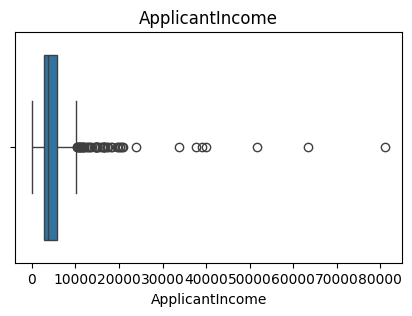

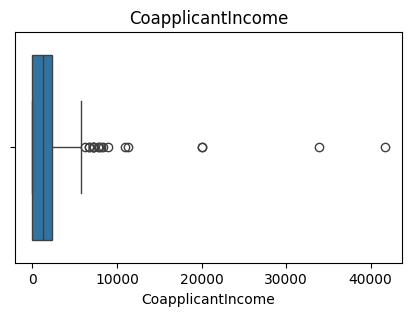

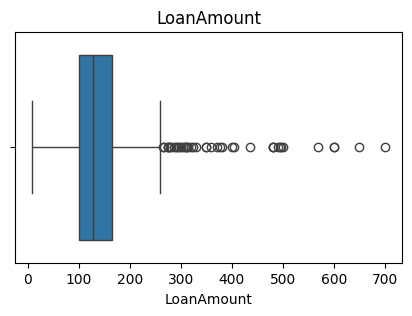

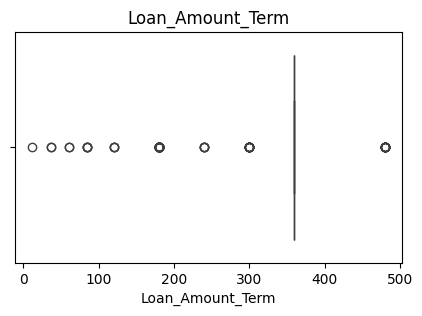

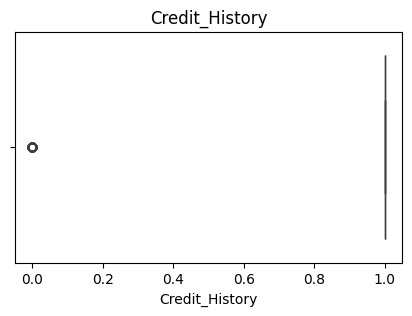

In [178]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [179]:
num_cols = ['ApplicantIncome',
            'CoapplicantIncome',
            'LoanAmount']

In [180]:
#IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = df[col].clip(lower, upper)

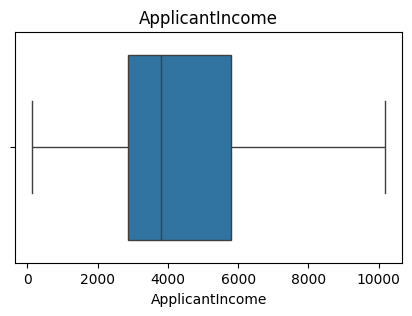

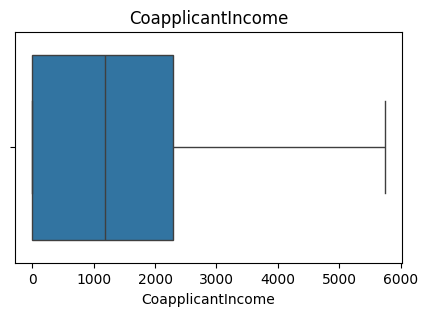

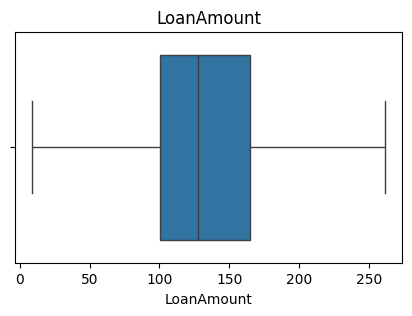

In [181]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [182]:
df['Credit_History'].value_counts()

,count
Credit_History,
1.0,525
0.0,89


* Outliers are extreme values that can affect analysis.
* Boxplots help visualize outliers.
* IQR method identifies and caps extreme values.

####Step 3: Encoding

In [183]:
df.drop("Loan_ID", axis=1, inplace=True)  # drop colum id

In [184]:
# label encoding for target col
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Loan_Status'] = le.fit_transform(df['Loan_Status'])

In [185]:
df.head(5)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,1


In [186]:
df['Credit_History'].value_counts()

,count
Credit_History,
1.0,525
0.0,89


In [187]:
df = pd.get_dummies(
    df,
    columns=['Gender',
             'Married',
             'Dependents',
             'Education',
             'Self_Employed',
             'Property_Area'],
    drop_first=True,
    dtype=int
)

In [188]:
df.head(5)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849.0,0.0,128.0,360.0,1.0,1,1,0,0,0,0,0,0,0,1
1,4583.0,1508.0,128.0,360.0,1.0,0,1,1,1,0,0,0,0,0,0
2,3000.0,0.0,66.0,360.0,1.0,1,1,1,0,0,0,0,1,0,1
3,2583.0,2358.0,120.0,360.0,1.0,1,1,1,0,0,0,1,0,0,1
4,6000.0,0.0,141.0,360.0,1.0,1,1,0,0,0,0,0,0,0,1


###step 4: Scaling

In [189]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ["ApplicantIncome",
        "CoapplicantIncome",
        "LoanAmount",
        "Loan_Amount_Term"]

df[cols] = scaler.fit_transform(df[cols])

In [190]:
df.head(5)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0.497164,-0.874587,-0.168041,0.273231,1.0,1,1,0,0,0,0,0,0,0,1
1,-0.013767,0.054395,-0.168041,0.273231,1.0,0,1,1,1,0,0,0,0,0,0
2,-0.652632,-0.874587,-1.280462,0.273231,1.0,1,1,1,0,0,0,0,1,0,1
3,-0.820924,0.578025,-0.311579,0.273231,1.0,1,1,1,0,0,0,1,0,0,1
4,0.558104,-0.874587,0.065209,0.273231,1.0,1,1,0,0,0,0,0,0,0,1


##Conclusion

The loan prediction dataset was successfully preprocessed by handling missing values, detecting and treating outliers, encoding categorical variables, and scaling numerical features. The resulting dataset is clean, consistent, and suitable for machine learning model development.